八点图

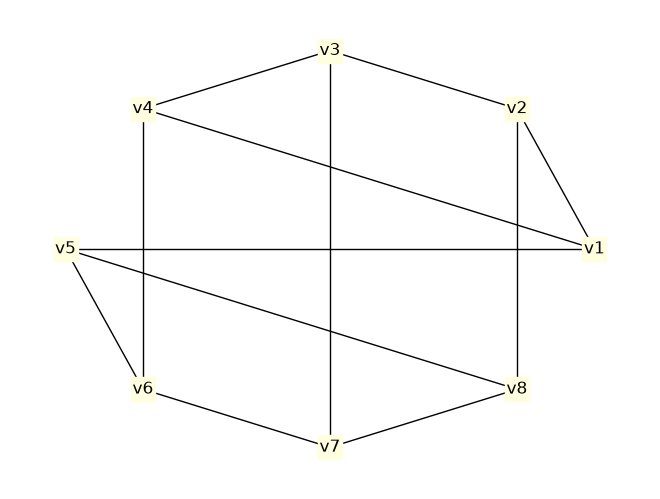

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.cubical_graph()

labels = {i: f"v{i+1}" for i in range(8)}

nx.draw(G, pos = nx.circular_layout(G), labels = labels, with_labels=True, node_color = "lightyellow", node_shape="s")

plt.show()

邻接表

In [4]:
G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3), (2, 4)])
print("邻接表:")

A = nx.to_numpy_array(G)
print(A)

邻接表:
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


权重矩阵

In [3]:
G = nx.Graph()
G.add_weighted_edges_from([(1, 3, 10,),(1, 4, 60),(2, 3, 5),(2, 4, 20),(3, 4, 1)])

w = nx.to_numpy_array(G, nodelist = [1,2,3,4], weight = "weight")
print(w)

[[ 0.  0. 10. 60.]
 [ 0.  0.  5. 20.]
 [10.  5.  0.  1.]
 [60. 20.  1.  0.]]


Dijkstra

In [5]:
G = nx.Graph()
G.add_weighted_edges_from([(1, 2, 6),(1, 3, 3),(1, 4, 1),(2, 5, 1),(3, 2, 2),(3, 4, 2),(4, 6, 10),(5, 4, 6),(5, 6, 4),(5, 7, 3),(5, 8, 6),(6, 5, 10),(6, 7, 2),(7, 8, 4),(9, 5, 2),(9, 8, 3)])
path = nx.dijkstra_path(G, source = 1, target = 8, weight = "weight")
distance = nx.dijkstra_path_length(G, source = 1, target = 8, weight = "weight")

print(path,distance)

[1, 3, 2, 5, 9, 8] 11


Floyd

In [6]:
G = nx.Graph()
G.add_weighted_edges_from([(1, 3, 10),
                           (1, 4, 60),
                           (2, 3, 5),
                           (2, 4, 20),
                           (3, 4, 1)
                           ])

dist = dict(nx.floyd_warshall(G, weight = "weight"))

for i in dist:
    print(i, dist[i])

nodes = [1, 2, 3, 4]

D = nx.floyd_warshall_numpy(
    G,
    nodelist = nodes,
    weight = "weight"
)
print(D)

1 defaultdict(<function floyd_warshall_predecessor_and_distance.<locals>.<lambda>.<locals>.<lambda> at 0x0000013E4EEAF380>, {1: 0, 3: 10, 4: 11, 2: 15})
3 defaultdict(<function floyd_warshall_predecessor_and_distance.<locals>.<lambda>.<locals>.<lambda> at 0x0000013E4EEAF420>, {3: 0, 1: 10, 2: 5, 4: 1})
4 defaultdict(<function floyd_warshall_predecessor_and_distance.<locals>.<lambda>.<locals>.<lambda> at 0x0000013E4EEAF1A0>, {4: 0, 1: 11, 3: 1, 2: 6})
2 defaultdict(<function floyd_warshall_predecessor_and_distance.<locals>.<lambda>.<locals>.<lambda> at 0x0000013E4EEAEF20>, {2: 0, 3: 5, 4: 6, 1: 15})
[[ 0. 15. 10. 11.]
 [15.  0.  5.  6.]
 [10.  5.  0.  1.]
 [11.  6.  1.  0.]]


$example 1$

In [ ]:
G = nx.DiGraph()
G.add_weighted_edges_from([(1, 2, 15),
                           (1, 3, 20),
                           (1, 4, 27),
                           (1, 5, 37),
                           (1, 6, 54),
                           (2, 3, 15),
                           (2, 4, 20),
                           (2, 5, 27),
                           (2, 6, 37),
                           (3, 4, 16),
                           (3, 5, 21),
                           (3, 6, 28),
                           (4, 5, 16),
                           (4, 6, 21),
                           (5, 6, 17)])
path = nx.dijkstra_path(G, source = 1, target = 6, weight = "weight")
length = nx.dijkstra_path_length(G, source = 1, target = 6, weight = "weight")
print(path,length)

[1, 3, 6] 48


$example2$

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
G = nx.Graph()
G.add_weighted_edges_from([(1, 2, 20),
                           (1, 5, 15),
                           (2, 3, 20),
                           (2, 4, 60),
                           (2, 5, 25),
                           (3, 4, 30),
                           (3, 5, 18),
                           (5, 6, 15)])
nodes = [1,2,3,4,5,6]
D = nx.floyd_warshall_numpy(G, nodelist = nodes, weight = "weight")
print(D)
d = np.array(D)
md = np.max(d,axis = 1)
print(md)
mmd = np.min(md)
print(mmd)

center = nx.center(G, weight = "weight")
print(f"最小{center}")

[[ 0. 20. 33. 63. 15. 30.]
 [20.  0. 20. 50. 25. 40.]
 [33. 20.  0. 30. 18. 33.]
 [63. 50. 30.  0. 48. 63.]
 [15. 25. 18. 48.  0. 15.]
 [30. 40. 33. 63. 15.  0.]]
[63. 50. 33. 63. 48. 63.]
33.0
最小[3]


$最小生成树，kruskal,prim$

kruskal结果:
0 -- 1, 权重 = 2
0 -- 2, 权重 = 1
0 -- 6, 权重 = 2
1 -- 8, 权重 = 1
2 -- 3, 权重 = 1
3 -- 4, 权重 = 1
5 -- 6, 权重 = 2
6 -- 7, 权重 = 3

prim结果:
0 -- 1, 权重 = 2
0 -- 2, 权重 = 1
0 -- 6, 权重 = 2
1 -- 8, 权重 = 1
2 -- 3, 权重 = 1
3 -- 4, 权重 = 1
5 -- 6, 权重 = 2
6 -- 7, 权重 = 3


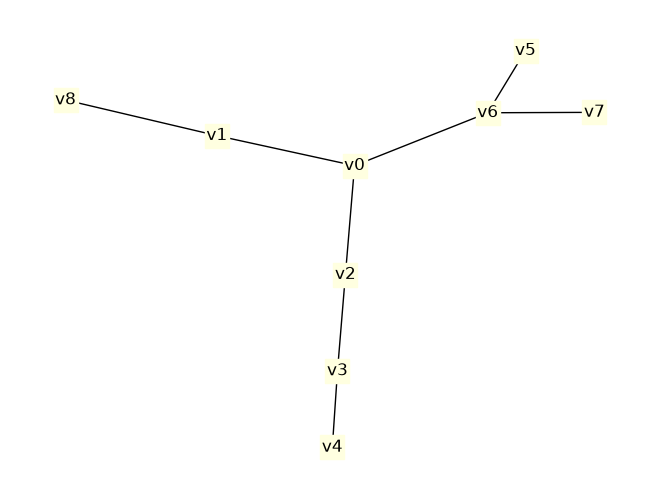

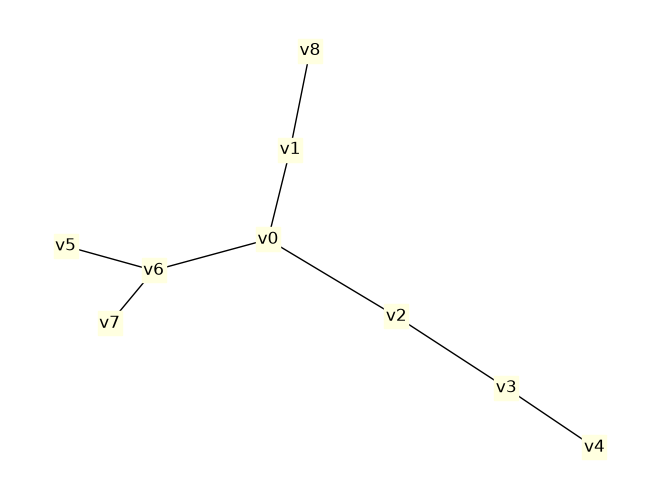

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

G = nx.Graph()
G.add_weighted_edges_from([(0, 1, 2),
                           (0, 2, 1),
                           (0, 3, 3),
                           (0, 4, 4),
                           (0, 5, 4),
                           (0, 6, 2),
                           (0, 7, 5),
                           (0, 8, 4),
                           (1, 2, 4),
                           (1, 8, 1),
                           (2, 3, 1),
                           (3, 4, 1),
                           (4, 5, 5),
                           (5, 6, 2),
                           (6, 7, 3),
                           (7, 8 ,5)])

if not nx.is_connected(G):
    raise ValueError("原图不连通，不存在生成树")

T_kruskal = nx.minimum_spanning_tree(
    G,
    weight = "weight",
    algorithm = "kruskal",
)

T_prim = nx.minimum_spanning_tree(
    G,
    weight = "weight",
    algorithm = "prim",
)

cost_kruskal = T_kruskal.size(weight = "weight")
cost_prim = T_prim.size(weight = "weight")
print("kruskal结果:")
for u, v, weight in sorted(T_kruskal.edges(data = "weight")):
    print(f"{u} -- {v}, 权重 = {weight}")

print("\nprim结果:")
for u, v, weight in sorted(T_prim.edges(data = "weight")):
    print(f"{u} -- {v}, 权重 = {weight}")



labels = {i: f"v{i}" for i in range(9)}

nx.draw(T_kruskal, labels = labels, with_labels=True, node_color = "lightyellow", node_shape="s")

plt.show()

nx.draw(T_prim, labels = labels, with_labels=True, node_color = "lightyellow", node_shape="s")

plt.show()